In [88]:
#import libraries
import pandas as pd
from matplotlib import pyplot as plt

#load dataset
df = pd.read_csv('data/fabiana/Malware_and_benign_recognition.csv')
#display
df.head()

,File,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
0,e_56_clip.exe,28672,24576,0,4864,4096,0,5368709120,7,49504,...,0.015920,24576,4096,0,7,85,0,0,0,0
1,8d9b19c7af036a2a3f6d710fdfb1f45ca1b476f2ad9484...,234496,72704,0,117581,4096,241664,268435456,4,320,...,3.054267,234496,7648,0,3,103,1,1,0,1
2,e0e908a62601140123531aca205c1d54e6a7ec851f09d4...,1024,1536,0,9134,8192,16384,268435456,3,34112,...,0.081539,1024,0,0,1,1,0,0,0,1
3,42438a67636a6981b4e3209449040f6b393f10fe0636df...,48640,75264,0,18028,4096,53248,4194304,5,32832,...,5.441382,48640,9440,0,3,13,0,0,0,1
4,d_233_CastLaunch.dll,73728,49152,0,9040,4096,0,6442450944,8,16736,...,0.015920,69632,4096,0,31,125,1,2,0,0


In [89]:
df.shape
#(rows, columns)

(1156, 27)

In [90]:
#inspect dataset
print("\n Dataset Info ")
print(df.info())


 Dataset Info 
<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   File                     1156 non-null   str    
 1   SizeOfCode               1156 non-null   int64  
 2   SizeOfInitializedData    1156 non-null   int64  
 3   SizeOfUninitializedData  1156 non-null   int64  
 4   AddressOfEntryPoint      1156 non-null   int64  
 5   BaseOfCode               1156 non-null   int64  
 6   BaseOfData               1156 non-null   int64  
 7   ImageBase                1156 non-null   uint64 
 8   NumberOfSections         1156 non-null   int64  
 9   DllCharacteristics       1156 non-null   int64  
 10  SizeOfImage              1156 non-null   int64  
 11  SizeOfHeaders            1156 non-null   int64  
 12  Characteristics          1156 non-null   int64  
 13  Subsystem                1156 non-null   int64  
 14  SectionCount       

In [105]:
#checking for null values
df.isna().sum()

File                       0
SizeOfCode                 0
SizeOfInitializedData      0
SizeOfUninitializedData    0
AddressOfEntryPoint        0
BaseOfCode                 0
BaseOfData                 0
ImageBase                  0
NumberOfSections           0
DllCharacteristics         0
SizeOfImage                0
SizeOfHeaders              0
Characteristics            0
Subsystem                  0
SectionCount               0
AvgSectionEntropy          0
MaxSectionEntropy          0
MinSectionEntropy          0
TextSectionSize            0
DataSectionSize            0
SuspiciousSectionNames     0
ImportedDLLs               0
ImportedFunctions          0
HasExportTable             0
ExportedFunctions          0
OverlaySize                0
Malicious                  0
dtype: int64

In [91]:
x = df.drop(columns=["File", "Malicious"]) #this will hold all the the columns except Malicious and File
x

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
0,28672,24576,0,4864,4096,0,5368709120,7,49504,57344,...,5.532363,0.015920,24576,4096,0,7,85,0,0,0
1,234496,72704,0,117581,4096,241664,268435456,4,320,319488,...,6.493744,3.054267,234496,7648,0,3,103,1,1,0
2,1024,1536,0,9134,8192,16384,268435456,3,34112,32768,...,4.207035,0.081539,1024,0,0,1,1,0,0,0
3,48640,75264,0,18028,4096,53248,4194304,5,32832,135168,...,7.693362,5.441382,48640,9440,0,3,13,0,0,0
4,73728,49152,0,9040,4096,0,6442450944,8,16736,126976,...,5.945090,0.015920,69632,4096,0,31,125,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,339968,217088,0,9776,4096,0,5368709120,8,49504,561152,...,6.120012,0.015920,335872,39744,0,42,306,0,0,0
1152,4096,20480,0,4784,4096,0,6442450944,6,16736,28672,...,5.760829,0.055274,4096,4096,0,3,23,1,8,0
1153,24576,102400,0,5280,4096,0,5368709120,8,49504,131072,...,7.149948,0.013127,20480,4096,0,19,82,0,0,0
1154,401408,172032,0,63872,4096,0,6442450944,8,16736,577536,...,6.184443,0.015920,397312,12352,0,12,338,1,8,0


In [92]:
y = df["Malicious"]
y

0       0
1       1
2       1
3       1
4       0
       ..
1151    0
1152    0
1153    0
1154    0
1155    0
Name: Malicious, Length: 1156, dtype: int64

In [99]:
x.shape

(1156, 25)

In [100]:
y.shape

(1156,)

In [101]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Malicious, dtype: int64

In [161]:
#split the data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10) 
#random_state=10  every time the code runs, the same split is generated
#test_size=0.2  20% of the split will be test and 80% will be train
x_train

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
274,1637376,4141568,0,56604,4096,1642496,268435456,9,320,6864896,...,7.313986,0.000000,1637376,55120,0,19,671,1,11,21224
218,11776,1536,0,19486,8192,24576,4194304,3,34144,40960,...,5.555388,0.081539,11776,0,0,1,1,0,0,0
618,163840,69632,0,94480,4096,0,6442450944,8,16736,237568,...,6.154350,0.015920,159744,4672,0,37,190,1,3,0
629,4096,5259264,0,4585,4096,8192,268435456,5,0,5267456,...,4.329516,0.000000,4096,4096,0,2,13,1,1,3
341,69632,167936,0,6832,4096,0,5368709120,7,49504,241664,...,7.513759,0.015920,65536,4096,0,33,150,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,4096,5259264,0,4585,4096,8192,268435456,5,0,5267456,...,3.930820,0.000000,4096,4096,0,2,13,1,1,3
733,4096,5259264,0,4585,4096,8192,268435456,5,0,5267456,...,4.383522,0.000000,4096,4096,0,2,13,1,1,3
1147,4096,5259264,0,4585,4096,8192,268435456,5,0,5267456,...,5.528175,0.000000,4096,4096,0,2,13,1,1,3
527,4096,5259264,0,4585,4096,8192,268435456,5,0,5267456,...,3.934920,0.000000,4096,4096,0,2,13,1,1,3


In [162]:
len(x_train)

924

In [163]:
len(x_test)

232

In [109]:
x_train.shape

(924, 25)

In [110]:
x_test.shape

(232, 25)

In [111]:
y_train.shape

(924,)

In [112]:
y_test.shape

(232,)

In [113]:
x_train.head()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
346,98304,61440,0,5600,4096,0,6442450944,7,16736,163840,...,6.166440,0.01592,94208,12224,0,24,146,1,14,0
431,200704,98304,0,11392,4096,0,6442450944,8,16736,303104,...,6.169920,0.01592,196608,12288,0,27,199,1,17,0
824,406528,375808,0,240700,4096,0,140697904939008,6,33120,798720,...,6.456566,0.00000,406348,253580,0,1,93,0,0,0
782,73728,45056,0,6080,4096,0,5368709120,7,49504,122880,...,6.099514,0.01592,69632,4096,0,27,158,0,0,0
713,61440,151552,0,6288,4096,0,5368709120,8,49504,217088,...,5.956242,0.01592,57344,11744,0,27,152,0,0,0


In [118]:
x_train.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
count,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,924.000000,924.000000,9.240000e+02,...,924.000000,924.000000,9.240000e+02,9.240000e+02,924.0,924.000000,924.000000,924.000000,924.000000,9.240000e+02
mean,5.819035e+05,1.787745e+06,5.292052e+04,1.101965e+06,5.364253e+04,3.814023e+05,1.996461e+16,6.694805,22040.035714,3.455188e+06,...,6.059409,0.376790,8.072793e+05,9.348144e+05,0.0,13.963203,128.248918,0.522727,54.320346,1.189346e+06
std,2.024936e+06,8.641658e+06,6.758315e+05,7.052567e+06,6.744372e+05,1.487534e+06,6.068530e+17,2.454336,19528.598137,1.280532e+07,...,1.218657,1.051910,9.037424e+06,1.094788e+07,0.0,14.363896,139.800914,0.499754,451.914551,8.004515e+06
min,0.000000e+00,5.120000e+02,0.000000e+00,0.000000e+00,4.096000e+03,0.000000e+00,6.553600e+04,2.000000,0.000000,1.228800e+04,...,1.266418,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2.048000e+04,3.686400e+04,0.000000e+00,4.944000e+03,4.096000e+03,0.000000e+00,2.684355e+08,5.000000,320.000000,1.146880e+05,...,5.844055,0.000000,8.192000e+03,4.096000e+03,0.0,2.000000,15.000000,0.000000,0.000000,0.000000e+00
50%,8.601600e+04,9.830400e+04,0.000000e+00,9.744000e+03,4.096000e+03,0.000000e+00,5.368709e+09,7.000000,16736.000000,3.727360e+05,...,6.184764,0.015920,6.758400e+04,4.096000e+03,0.0,8.000000,103.500000,1.000000,1.000000,0.000000e+00
75%,3.463680e+05,5.738240e+05,0.000000e+00,9.594350e+04,4.096000e+03,4.096000e+04,6.442451e+09,8.000000,34144.000000,3.426304e+06,...,6.608494,0.020393,2.672640e+05,1.484800e+04,0.0,22.250000,166.000000,1.000000,3.000000,1.306000e+03
max,3.564544e+07,2.161132e+08,1.363558e+07,1.184213e+08,1.363968e+07,1.379942e+07,1.844674e+19,21.000000,49632.000000,2.164695e+08,...,7.999989,7.488385,2.684396e+08,2.685379e+08,0.0,81.000000,1664.000000,1.000000,8843.000000,1.012587e+08


In [115]:
x_test.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
count,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,232.000000,232.000000,2.320000e+02,...,232.000000,232.000000,2.320000e+02,2.320000e+02,232.0,232.000000,232.000000,232.000000,232.000000,2.320000e+02
mean,6.129545e+05,1.058051e+06,4.748138e+04,6.836008e+05,4.542676e+04,4.681446e+05,2.385354e+17,6.646552,23316.827586,3.152967e+06,...,6.040813,0.364099,5.544790e+05,1.390431e+06,0.0,14.793103,155.823276,0.534483,45.456897,1.442498e+06
std,1.745962e+06,2.190172e+06,5.852256e+05,2.660618e+06,5.793418e+05,1.969830e+06,2.088565e+18,2.171258,18746.710921,1.021216e+07,...,1.184503,1.031009,1.714787e+06,9.835523e+06,0.0,14.786221,200.925820,0.499888,270.835948,8.777063e+06
min,0.000000e+00,1.536000e+03,0.000000e+00,0.000000e+00,4.096000e+03,0.000000e+00,6.553600e+04,2.000000,0.000000,2.048000e+04,...,1.265017,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2.316800e+04,3.686400e+04,0.000000e+00,5.056000e+03,4.096000e+03,0.000000e+00,2.684355e+08,5.000000,344.000000,1.064960e+05,...,5.853584,0.000000,1.459200e+04,4.096000e+03,0.0,2.000000,16.500000,0.000000,0.000000,0.000000e+00
50%,9.216000e+04,9.830400e+04,0.000000e+00,1.087200e+04,4.096000e+03,0.000000e+00,5.368709e+09,7.000000,16736.000000,3.665920e+05,...,6.174999,0.015920,8.012800e+04,4.096000e+03,0.0,9.000000,106.500000,1.000000,1.000000,0.000000e+00
75%,3.441920e+05,3.737600e+05,0.000000e+00,1.106400e+05,4.096000e+03,1.024000e+04,6.442451e+09,8.000000,34144.000000,3.140608e+06,...,6.586364,0.021614,2.694400e+05,1.528900e+04,0.0,24.000000,196.250000,1.000000,3.000000,3.250000e+00
max,1.433139e+07,1.227922e+07,8.798208e+06,2.091836e+07,8.802304e+06,1.434419e+07,1.844674e+19,17.000000,49632.000000,7.831142e+07,...,7.999936,6.068496,1.433139e+07,7.792973e+07,0.0,76.000000,1945.000000,1.000000,2416.000000,8.318443e+07


In [165]:
#printing information aboout the length of splitted datasets
print(f"{len(x)} - number of elements in the entire dataset.")
print(f"{len(x_train)} - number of training elements.")
print(f"{len(x_test)} - number of testing elements.")
print(f"{len(x_train) + len(x_test)} - sum of training and testing elements.")

1156 - number of elements in the entire dataset.
924 - number of training elements.
232 - number of testing elements.
1156 - sum of training and testing elements.


In [166]:
df.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
count,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1156.000000,1156.000000,1.156000e+03,...,1156.000000,1.156000e+03,1.156000e+03,1156.0,1156.000000,1156.000000,1156.000000,1156.000000,1.156000e+03,1156.000000
mean,5.881352e+05,1.641301e+06,5.182893e+04,1.018003e+06,5.199369e+04,3.988108e+05,6.383003e+16,6.685121,22296.277682,3.394535e+06,...,0.374243,7.565443e+05,1.026253e+06,0.0,14.129758,133.782872,0.525087,52.541522,1.240152e+06,0.495675
std,1.971440e+06,7.792484e+06,6.584114e+05,6.418082e+06,6.562292e+05,1.595476e+06,1.083692e+18,2.399384,19372.978532,1.232523e+07,...,1.047318,8.115890e+06,1.073135e+07,0.0,14.446993,154.320537,0.499586,421.767264,8.162107e+06,0.500198
min,0.000000e+00,5.120000e+02,0.000000e+00,0.000000e+00,4.096000e+03,0.000000e+00,6.553600e+04,2.000000,0.000000,1.228800e+04,...,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2.048000e+04,3.686400e+04,0.000000e+00,4.944000e+03,4.096000e+03,0.000000e+00,2.684355e+08,5.000000,320.000000,1.146880e+05,...,0.000000,8.192000e+03,4.096000e+03,0.0,2.000000,15.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,8.601600e+04,9.830400e+04,0.000000e+00,1.007200e+04,4.096000e+03,0.000000e+00,5.368709e+09,7.000000,16736.000000,3.706880e+05,...,0.015920,6.963200e+04,4.096000e+03,0.0,8.000000,105.000000,1.000000,1.000000,0.000000e+00,0.000000
75%,3.461120e+05,4.970240e+05,0.000000e+00,1.004785e+05,4.096000e+03,3.276800e+04,6.442451e+09,8.000000,34144.000000,3.386368e+06,...,0.020393,2.672640e+05,1.484800e+04,0.0,23.000000,171.000000,1.000000,3.000000,5.182500e+02,1.000000
max,3.564544e+07,2.161132e+08,1.363558e+07,1.184213e+08,1.363968e+07,1.434419e+07,1.844674e+19,21.000000,49632.000000,2.164695e+08,...,7.488385,2.684396e+08,2.685379e+08,0.0,81.000000,1945.000000,1.000000,8843.000000,1.012587e+08,1.000000


Text(0.5, 1.0, 'Benign vs Malicious')

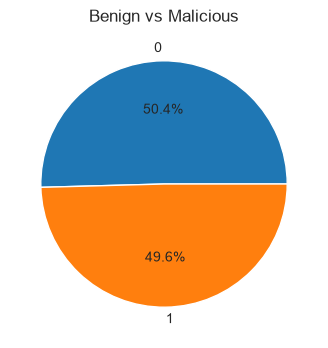

In [164]:
#visualizations
import seaborn as sns

sns.set_style('darkgrid') #color
plt.figure(figsize=(6,4)) #size
plt.pie(df['Malicious'].value_counts(), labels = df['Malicious'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')

In [167]:
#train and evaluate a binary classification model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

#predictions
model.predict(x_test)

array([0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130431, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130434,
       0.49130434, 0.49130434, 0.49130434, 0.49130434, 0.49130

In [168]:
y_test

765     0
903     1
1107    1
836     1
278     1
       ..
82      1
657     0
997     1
443     0
859     1
Name: Malicious, Length: 232, dtype: int64

In [170]:
model.score(x_test,y_test)
#evalutes performance after the split / accuracy of the model's predictions

-0.0026941241426476914